# Example for parametric method


In [10]:
# %pip install bssunfold

In [11]:
from bssunfold import Detector, RF_LANL
from bssunfold.utils.plotting import plot_comparison

## Load the response functions file for the BSS
- first column: Energy in MeV
- other columns: detector responses for the set of moderator spheres

In [12]:
det = Detector(RF_LANL)

In [13]:
# reference spectrum ISO Cf-252.
reference_spectrum = {
    "E_MeV": [
        1e-09,
        1.5848931924611136e-09,
        2.5118864315095803e-09,
        3.981071705534973e-09,
        6.309573444801934e-09,
        1e-08,
        1.5848931924611143e-08,
        2.511886431509581e-08,
        3.9810717055349736e-08,
        6.309573444801934e-08,
        1.0000000000000001e-07,
        1.5848931924611143e-07,
        2.5118864315095823e-07,
        3.9810717055349735e-07,
        6.309573444801937e-07,
        1.0000000000000002e-06,
        1.584893192461114e-06,
        2.5118864315095823e-06,
        3.981071705534973e-06,
        6.309573444801937e-06,
        1e-05,
        1.584893192461114e-05,
        2.5118864315095822e-05,
        3.9810717055349776e-05,
        6.309573444801943e-05,
        0.0001,
        0.00015848931924611142,
        0.0002511886431509582,
        0.0003981071705534978,
        0.0006309573444801943,
        0.001,
        0.0015848931924611143,
        0.0025118864315095825,
        0.003981071705534978,
        0.006309573444801942,
        0.01,
        0.01584893192461114,
        0.025118864315095826,
        0.039810717055349776,
        0.06309573444801943,
        0.1,
        0.15848931924611173,
        0.25118864315095824,
        0.3981071705534969,
        0.6309573444801944,
        1.0,
        1.5848931924611174,
        2.5118864315095824,
        3.9810717055349856,
        6.309573444801943,
        10.0,
        15.848931924611176,
        25.118864315095824,
        39.810717055349855,
        63.09573444801943,
        100.0,
        158.48931924611173,
        251.18864315095823,
        398.1071705534986,
        630.9573444801944,
    ],
    "Phi": [
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0002193244132568562,
        0.000922,
        0.0017977302145640818,
        0.0033934229230273556,
        0.00638236969883396,
        0.01212580290671056,
        0.0237,
        0.04468185467401807,
        0.0822779218679577,
        0.1450462719353082,
        0.2413649401952857,
        0.359,
        0.45221093414611185,
        0.4338707690763234,
        0.2708850368693928,
        0.0856762250762,
        0.00427,
        0.0004258199483775139,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
    ],
}

## Get effective readings for spectra

In [14]:
readings = det.get_effective_readings_for_spectra(reference_spectrum)

In [15]:
results = {
    "Bayes-param": det.unfold_bayesian_parametric(readings),
    "Bayes-fruit": det.unfold_fruit_like(readings),
    "Hybrid": det.unfold_hybrid_parametric(readings),
    "FRUIT-Param": det.unfold_parametric(readings),
}


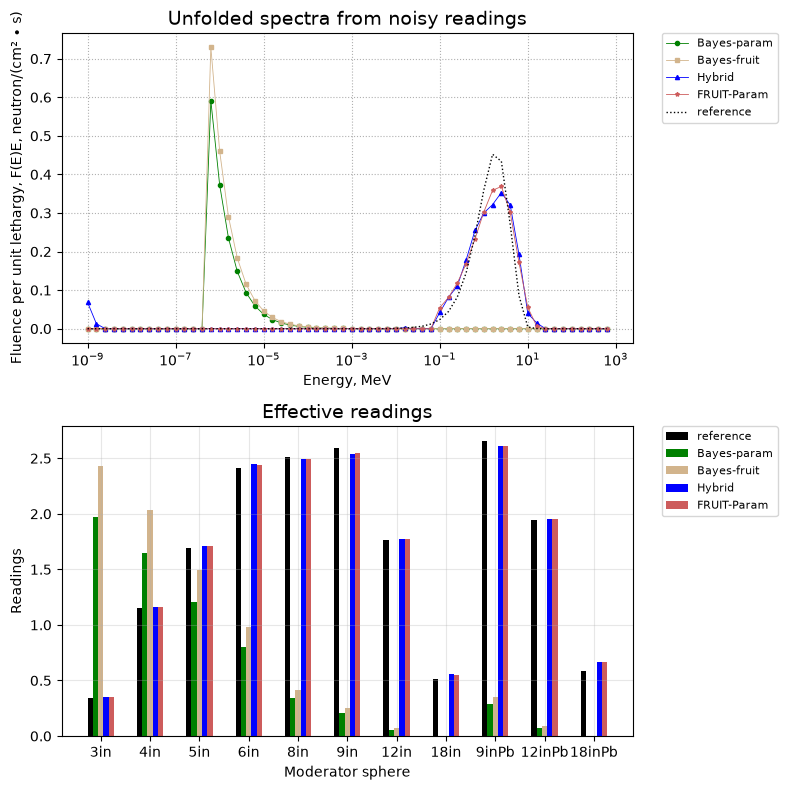

In [16]:
fig, ax = plot_comparison(
    results=results, 
    readings=readings, 
    reference_spectrum=reference_spectrum, 
)

# Comparison

In [17]:
det.compare(reference_spectrum,results['Bayes-param'])

{'kl_divergence': 16.532016542883518,
 'cross_entropy': 18.62532598648345,
 'entropy_difference_percent': 789.7550261108529,
 'wasserstein_dist': 0.014085044689050571,
 'energy_dist': 0.028796209261552935,
 'kolmogorov_smirnov_stat': 0.7,
 'pearson_r': -0.10082787520113057,
 'spearman_r': 0.004970163644385381,
 'mean_squared_error': 0.021196617139235593,
 'root_mean_squared_error': 0.14559058053059473,
 'mean_absolute_error': 0.06283013185796851,
 'mape': 98.16990947030821,
 'r2_score': -1.07528985109529,
 'max_error': 0.5911576025453743,
 'median_absolute_error': 0.0009108110698683702,
 'cosine_similarity': 4.817062614274089e-07,
 'total_flux_ratio': 0.7387790764962916,
 'mmd_rbf': 0.00842377015982243,
 'chi_squared': 25074331.822714876,
 'g_test': 33.064033085767036,
 'freeman_tukey': 7.992403324963407,
 'cressie_read': 143434.4554770709,
 'anderson_darling': 38.07215099051486,
 'standardized_mean_difference': 0.09559397104557267,
 'wilcoxon_test': 788.0,
 'mannwhitneyu_test': 941.0,

# Paramentric with QP

solver_backend format: "cvxpy", "cvxpy:ECOS", "qpsolvers", "qpsolvers:osqp", or "auto".

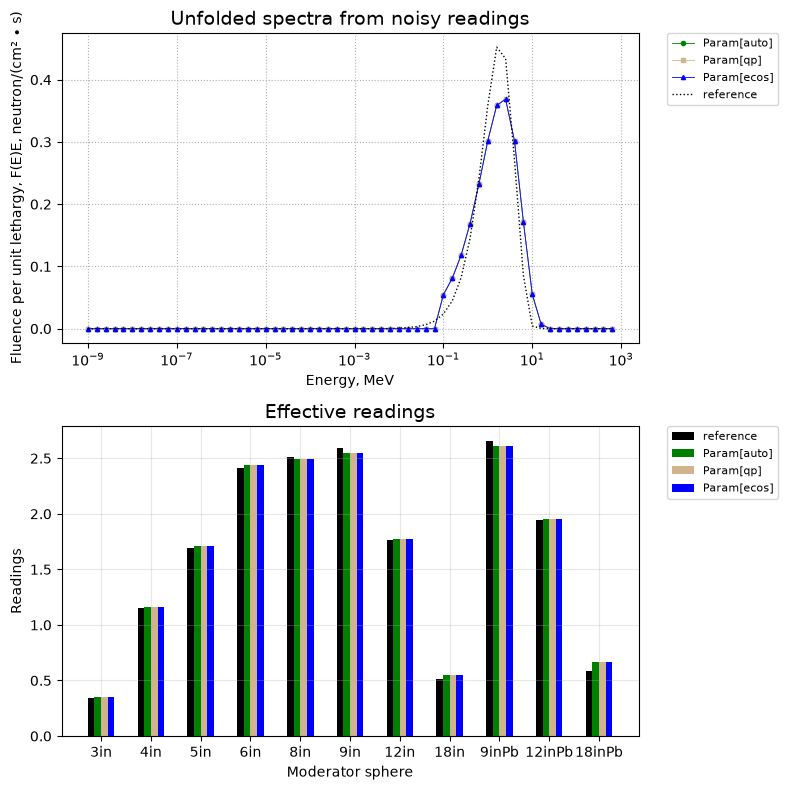

{'kl_divergence': 0.3461576805441582,
 'cross_entropy': 2.4394671241440817,
 'entropy_difference_percent': 16.536383648509272,
 'wasserstein_dist': 0.008713413717267877,
 'energy_dist': 0.022265855079282647,
 'kolmogorov_smirnov_stat': 0.7,
 'pearson_r': 0.9764126449947289,
 'spearman_r': 0.6182540803708905,
 'mean_squared_error': 0.0005269762086925531,
 'root_mean_squared_error': 0.022955962377834503,
 'mean_absolute_error': 0.009181185986642007,
 'mape': 211.40977256646028,
 'r2_score': 0.9484055228961988,
 'max_error': 0.09344947573800494,
 'median_absolute_error': 2.5519543955262128e-08,
 'cosine_similarity': 0.9785825680399673,
 'total_flux_ratio': 1.0243262790253036,
 'mmd_rbf': 0.020817670889374806,
 'chi_squared': 6961235882.650117,
 'g_test': 0.6923153610883164,
 'freeman_tukey': 0.18170019131125537,
 'cressie_read': 1306080.2025338889,
 'anderson_darling': 38.116296406093085,
 'standardized_mean_difference': -0.009038190486402321,
 'wilcoxon_test': 499.0,
 'mannwhitneyu_test'

In [18]:
results_qp = {
    "Param[auto]": det.unfold_parametric(readings),
    "Param[qp]": det.unfold_parametric(readings,solver_backend ="qpsolvers"),
    "Param[ecos]": det.unfold_parametric(readings, solver_backend ="cvxpy:ECOS"),
}

fig, ax = plot_comparison(
    results=results_qp, 
    readings=readings, 
    reference_spectrum=reference_spectrum, 
)

det.compare(reference_spectrum,results_qp['Param[auto]'])